In [48]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image
from glob import glob
import time
import utils

In [49]:
import sys
sys.path.append('../../models')

from densenet import DenseNet2D
from mobilenet_v1_AP import MobileNet2D_V1_AP
from mobilenet_v1 import MobileNet2D_V1
from auto_roi import AutoROI

In [50]:
root_dir = r"C:\Users\omarh\OneDrive - Georgia Institute of Technology\openEDS2019"
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [51]:
def preprocess_image(img, apply_preprocessing=True):
    if not apply_preprocessing:
        return img

    gamma = 0.8
    gamma_LUT = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    img = cv2.LUT(img, gamma_LUT)

    p_low, p_high = np.percentile(img, (1, 99))
    lut_indices = np.arange(256)
    stretch_LUT = np.clip((lut_indices - p_low) * (255.0 / max(p_high - p_low, 1)), 0, 255).astype(np.uint8)
    img = cv2.LUT(img, stretch_LUT)

    return img

In [52]:
def apply_roi_prediction(img0, img1, label1, bbox_model, apply_roi=True):
    h, w = img1.shape

    if not apply_roi:
        return img1, label1

    img0_resized = cv2.resize(img0, (64, 64), interpolation=cv2.INTER_LINEAR)
    img1_resized = cv2.resize(img1, (64, 64), interpolation=cv2.INTER_LINEAR)

    img0_tensor = torch.from_numpy(img0_resized).unsqueeze(0).float() / 255.0
    img1_tensor = torch.from_numpy(img1_resized).unsqueeze(0).float() / 255.0

    diff = img1_tensor - img0_tensor
    input_tensor = torch.cat((img1_tensor, diff), dim=0).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_bbox = bbox_model(input_tensor).cpu().squeeze(0)

    xmin, xmax, ymin, ymax = pred_bbox
    xmin = int(max(0, min(w-1, xmin.item())))
    xmax = int(max(0, min(w-1, xmax.item())))
    ymin = int(max(0, min(h-1, ymin.item())))
    ymax = int(max(0, min(h-1, ymax.item())))

    if xmin >= xmax or ymin >= ymax:
        cropped_img = img1
        cropped_label = label1
    else:
        cropped_img = img1[ymin:ymax, xmin:xmax]
        cropped_label = label1[ymin:ymax, xmin:xmax]

    return cropped_img, cropped_label

In [53]:
def run_segmentation(img, model, model_type='custom'):
    if model_type == 'ritnet':
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        img_tensor = transform(Image.fromarray(img)).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(img_tensor)
        pred_map = utils.get_predictions(output)
        pred_img = pred_map.cpu().numpy().squeeze(0)
        return pred_img
    else:
        transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])
        img_tensor = transform(Image.fromarray(img)).unsqueeze(0).to(device)
        with torch.no_grad():
            output = model(img_tensor)
        pred_img = output.argmax(dim=1).cpu().numpy().squeeze(0)
        return pred_img

In [54]:
def calculate_mean_iou(pred, label):
    classes = [1, 2, 3]  # sclera, iris, pupil
    ious = []

    for cls in classes:
        pred_cls = pred == cls
        label_cls = label == cls
        intersection = np.logical_and(pred_cls, label_cls).sum()
        union = np.logical_or(pred_cls, label_cls).sum()

        if union == 0:
            iou = np.nan
        else:
            iou = intersection / union

        ious.append(iou)

    return np.nanmean(ious), ious  # mean IoU across classes, list of individual IoUs

In [55]:
def load_test_subjects(split_file):
    with open(split_file, 'r') as f:
        lines = f.readlines()
    
    test_subjects = []
    recording = False
    for line in lines:
        line = line.strip()
        if line == 'Test Subjects:':
            recording = True
            continue
        if recording:
            if line:
                test_subjects.append(line)
    return test_subjects

# Example Usage
split_file = 'subject_split.txt'
test_subjects = load_test_subjects(split_file)
print(f"Found {len(test_subjects)} test subjects")

Found 19 test subjects


In [56]:
def build_dataset(root_dir, test_subjects):
    image_paths = []
    label_paths = []

    for subj in test_subjects:
        subject_dir = os.path.join(root_dir, 'openEDS', 'openEDS', subj)
        images = sorted([f for f in os.listdir(subject_dir) if f.endswith('.png')])

        for img_name in images:
            img_path = os.path.join(subject_dir, img_name)
            label_path = os.path.join(subject_dir, img_name.replace('.png', '.npy'))
            if os.path.exists(label_path):
                image_paths.append(img_path)
                label_paths.append(label_path)

    return list(zip(image_paths, label_paths))

# Example Usage
dataset = build_dataset(root_dir, test_subjects)
print(f"Total samples: {len(dataset)}")


Total samples: 2811


In [57]:
weights_path = r"C:\Users\omarh\Documents\GaTech\VisualTracking\weights"

# Load your bbox model and segmentation models
bbox_model = AutoROI()
bbox_model.load_state_dict(torch.load(os.path.join(weights_path, 'ablation', 'auto_roi.pth'), map_location=device))
bbox_model = bbox_model.to(device)
bbox_model.eval()

bbox_model_nopp = AutoROI()
bbox_model_nopp.load_state_dict(torch.load(os.path.join(weights_path, 'ablation', 'auto_roi_nopp.pth'), map_location=device))
bbox_model_nopp = bbox_model_nopp.to(device)
bbox_model_nopp.eval()

sertnet_ap_model = MobileNet2D_V1_AP(dropout=True, prob=0.2)
sertnet_ap_model.load_state_dict(torch.load(os.path.join(weights_path, 'ablation', 'TRAIN_MOBILE_V1_AP_ROI9.pkl'), map_location=device))
sertnet_ap_model = sertnet_ap_model.to(device)
sertnet_ap_model.eval()

sertnet_model = MobileNet2D_V1(dropout=True, prob=0.2)
sertnet_model.load_state_dict(torch.load(os.path.join(weights_path, 'ablation', 'TRAIN_MOBILE_V1.pkl'), map_location=device))
sertnet_model = sertnet_model.to(device)
sertnet_model.eval()

ritnet_model = DenseNet2D(dropout=True, prob=0.2)
ritnet_model.load_state_dict(torch.load(os.path.join(weights_path, 'ablation', 'dense_net9.pkl')))  # If .pkl format
ritnet_model = ritnet_model.to(device)
ritnet_model.eval()

C:\Users\omarh\AppData\Local\Temp\ipykernel_4732\2791735240.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  bbox_model.load_state_dict(torch.load(os.path.join(weights_pa

DenseNet2D(
  (down_block1): DenseNet2D_down_block(
    (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv21): Conv2d(33, 32, kernel_size=(1, 1), stride=(1, 1))
    (conv22): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv31): Conv2d(65, 32, kernel_size=(1, 1), stride=(1, 1))
    (conv32): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (max_pool): AvgPool2d(kernel_size=None, stride=None, padding=0)
    (relu): LeakyReLU(negative_slope=0.01)
    (dropout1): Dropout(p=0.2, inplace=False)
    (dropout2): Dropout(p=0.2, inplace=False)
    (dropout3): Dropout(p=0.2, inplace=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (down_block2): DenseNet2D_down_block(
    (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (conv21): Conv2d(64, 32, kernel_size=(1, 1), stride=(1, 1))
    (conv22): Conv2d(32, 32, kernel_size=(3, 3), stride=

In [63]:
experiments = [
    {'apply_preprocessing': True,  'apply_roi': True,  'segmentation_model': sertnet_ap_model, 'model_type': 'custom', 'label': 'PP+ROI+SERTNetV1_AP'},
    {'apply_preprocessing': True,  'apply_roi': False, 'segmentation_model': sertnet_model, 'model_type': 'ritnet', 'label': 'PP+SERTNetV1'},
    {'apply_preprocessing': False, 'apply_roi': True,  'segmentation_model': sertnet_ap_model, 'model_type': 'custom', 'label': 'ROI+SERTNetV1_AP'},
    {'apply_preprocessing': False, 'apply_roi': False, 'segmentation_model': sertnet_model, 'model_type': 'ritnet', 'label': 'SERTNetV1'},
    {'apply_preprocessing': False, 'apply_roi': False, 'segmentation_model': ritnet_model, 'model_type': 'ritnet', 'label': 'RITNet'},
]

In [64]:
from tqdm import tqdm
import time

results = []
timings = []  # Store average ms per experiment

for exp in experiments:
    print(f"Running Experiment: {exp['label']}")
    all_mean_ious = []
    all_times = []

    for idx in tqdm(range(1, len(dataset)), desc=f"Processing {exp['label']}"):
        img0_path, _ = dataset[idx-1]
        img1_path, label_path = dataset[idx]

        # 🕒 Start timing
        start_time = time.perf_counter()

        img0 = cv2.imread(img0_path)
        img1 = cv2.imread(img1_path)
        label = np.load(label_path)

        img0_gray = cv2.cvtColor(img0, cv2.COLOR_BGR2GRAY)
        img1_gray = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)

        img0_gray = preprocess_image(img0_gray, apply_preprocessing=exp['apply_preprocessing'])
        img1_gray = preprocess_image(img1_gray, apply_preprocessing=exp['apply_preprocessing'])

        if exp['apply_preprocessing']:
            img1_processed, label_processed = apply_roi_prediction(
                img0_gray, img1_gray, label, bbox_model, apply_roi=exp['apply_roi'])
        else:
            img1_processed, label_processed = apply_roi_prediction(
                img0_gray, img1_gray, label, bbox_model_nopp, apply_roi=exp['apply_roi'])

        pred = run_segmentation(img1_processed, exp['segmentation_model'], model_type=exp['model_type'])

        # 🕒 End timing
        end_time = time.perf_counter()
        elapsed_time_ms = (end_time - start_time) * 1000  # Convert seconds → milliseconds
        all_times.append(elapsed_time_ms)

        mean_iou, _ = calculate_mean_iou(pred, label_processed)
        all_mean_ious.append(mean_iou)

    avg_mean_iou = np.nanmean(all_mean_ious)
    avg_time_ms = np.mean(all_times)

    results.append((exp['label'], avg_mean_iou))
    timings.append((exp['label'], avg_time_ms))

    print(f"{exp['label']}: Mean IoU = {avg_mean_iou:.4f}, Avg Time = {avg_time_ms:.2f} ms")

Running Experiment: PP+ROI+SERTNetV1_AP


Processing PP+ROI+SERTNetV1_AP:   1%|          | 31/2810 [00:00<00:41, 67.75it/s]C:\Users\omarh\AppData\Local\Temp\ipykernel_4732\1301122174.py:18: RuntimeWarning: Mean of empty slice
  return np.nanmean(ious), ious  # mean IoU across classes, list of individual IoUs
Processing PP+ROI+SERTNetV1_AP: 100%|██████████| 2810/2810 [00:35<00:00, 78.80it/s]


PP+ROI+SERTNetV1_AP: Mean IoU = 0.9086, Avg Time = 12.23 ms
Running Experiment: PP+SERTNetV1


Processing PP+SERTNetV1: 100%|██████████| 2810/2810 [01:10<00:00, 39.75it/s]


PP+SERTNetV1: Mean IoU = 0.9394, Avg Time = 23.86 ms
Running Experiment: ROI+SERTNetV1_AP


...

ROI+SERTNetV1_AP: Mean IoU = 0.8611, Avg Time = 9.80 ms
Running Experiment: SERTNetV1


Processing SERTNetV1: 100%|██████████| 2810/2810 [01:03<00:00, 44.15it/s]


SERTNetV1: Mean IoU = 0.9205, Avg Time = 21.37 ms
Running Experiment: RITNet


Processing RITNet: 100%|██████████| 2810/2810 [00:53<00:00, 52.28it/s]

RITNet: Mean IoU = 0.9231, Avg Time = 17.88 ms


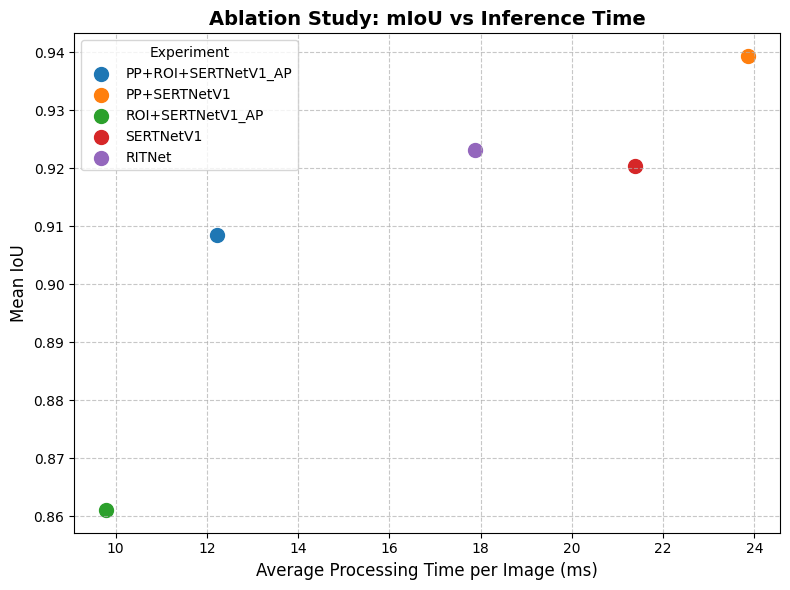

In [65]:
import matplotlib.pyplot as plt

# Separate labels and values
labels, mean_ious = zip(*results)
_, avg_times_ms = zip(*timings)

# Create the scatter plot
plt.figure(figsize=(8,6))

for label, iou, time_ms in zip(labels, mean_ious, avg_times_ms):
    plt.scatter(time_ms, iou, label=label, s=100)  # s=100 makes points bigger for clarity

plt.xlabel('Average Processing Time per Image (ms)', fontsize=12)
plt.ylabel('Mean IoU', fontsize=12)
plt.title('Ablation Study: mIoU vs Inference Time', fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.7)

plt.legend(title="Experiment", fontsize=10)
plt.tight_layout()
plt.show()